In [ ]:
# =========================
# Cell 1: Install packages
# =========================
!pip -q install datasets scikit-learn pillow matplotlib torch torchvision

In [ ]:
# =========================
# Cell 2: Imports
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

import torchvision.models as models
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# =========================
# Cell 3: Settings
# =========================
SEED = 42
MAX_SAMPLES = 1200   # start here; raise to 2000 later if it runs fast enough
BATCH_SIZE = 32
IMG_SIZE = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TARGET_LABELS = ["Pneumonia", "Edema", "Consolidation", "Pleural Effusion"]

# Hugging Face class values in this mirror:
# 0 = unlabeled
# 1 = uncertain
# 2 = absent
# 3 = present
UNCERTAIN_VALUE = 1
PRESENT_VALUE = 3

print("Device:", DEVICE)

Device: cuda


In [ ]:
# =========================
# Cell 4: Load dataset
# =========================
# This mirror includes the image itself plus metadata/labels.
ds = load_dataset("danjacobellis/chexpert", split="train")

print(ds)
print(ds.features)

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

data/train-00000-of-00023.parquet:   0%|          | 0.00/487M [00:00<?, ?B/s]

data/train-00001-of-00023.parquet:   0%|          | 0.00/486M [00:00<?, ?B/s]

...

data/validation-00000-of-00001.parquet:   0%|          | 0.00/12.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/223414 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/234 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/23 [00:00<?, ?it/s]

Dataset({
    features: ['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices', 'image'],
    num_rows: 223414
})
{'Path': Value('string'), 'Sex': ClassLabel(names=['Male', 'Female']), 'Age': Value('int64'), 'Frontal/Lateral': ClassLabel(names=['Frontal', 'Lateral']), 'AP/PA': ClassLabel(names=['AP', 'PA', '']), 'No Finding': ClassLabel(names=['unlabeled', 'uncertain', 'absent', 'present']), 'Enlarged Cardiomediastinum': ClassLabel(names=['unlabeled', 'uncertain', 'absent', 'present']), 'Cardiomegaly': ClassLabel(names=['unlabeled', 'uncertain', 'absent', 'present']), 'Lung Opacity': ClassLabel(names=['unlabeled', 'uncertain', 'absent', 'present']), 'Lung Lesion': ClassLabel(names=['unlabeled', 'uncertain', 'absent', 'present']), 'Edema': ClassLabel(names=['unlabele

In [ ]:
# =========================
# Cell 5: Convert to DataFrame and build Severe label
# =========================
# Pull only needed columns into pandas for filtering
cols = ["image", "Path", "Sex", "Age"] + TARGET_LABELS
df = ds.select_columns(cols).to_pandas()

# Drop missing metadata
df = df.dropna(subset=["image", "Sex", "Age"] + TARGET_LABELS).copy()

# Remove uncertain rows on the four target labels
for col in TARGET_LABELS:
    df = df[df[col] != UNCERTAIN_VALUE]

# Build severe label: 1 if any target pathology is present
df["Severe"] = df[TARGET_LABELS].apply(lambda row: int(any(v == PRESENT_VALUE for v in row)), axis=1)

# Encode sex
df["sex"] = (df["Sex"].astype(str).str.lower() == "male").astype(int)
df["age"] = pd.to_numeric(df["Age"], errors="coerce")
df = df.dropna(subset=["age"]).copy()

print("Filtered rows:", len(df))
print(df["Severe"].value_counts(dropna=False))
print(df["Severe"].value_counts(normalize=True))

Filtered rows: 163596
Severe
1    92248
0    71348
Name: count, dtype: int64
Severe
1    0.563877
0    0.436123
Name: proportion, dtype: float64


In [ ]:
# =========================
# Cell 6: Sample a manageable subset
# =========================
# Stratified sample so class balance stays reasonable
if len(df) > MAX_SAMPLES:
    sampled_idx, _ = train_test_split(
        df.index,
        train_size=MAX_SAMPLES,
        random_state=SEED,
        stratify=df["Severe"]
    )
    df = df.loc[sampled_idx].reset_index(drop=True)
else:
    df = df.reset_index(drop=True)

print("Subset rows used:", len(df))
print(df["Severe"].value_counts())
print(df["Severe"].value_counts(normalize=True))

Subset rows used: 1200
Severe
1    677
0    523
Name: count, dtype: int64
Severe
1    0.564167
0    0.435833
Name: proportion, dtype: float64


In [ ]:
# =========================
# Cell 7: Train/test split
# =========================
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["Severe"]
)

print("Train:", len(train_df), "Test:", len(test_df))

Train: 960 Test: 240


In [ ]:
# =========================
# Cell 8: Torch dataset for image embeddings
# =========================
import io

class HFDatasetWrapper(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        img = row["image"]

        # Case 1: already a PIL image
        if isinstance(img, Image.Image):
            pil_img = img.convert("RGB")

        # Case 2: Hugging Face image dict with raw bytes
        elif isinstance(img, dict) and img.get("bytes") is not None:
            pil_img = Image.open(io.BytesIO(img["bytes"])).convert("RGB")

        # Case 3: Hugging Face image dict with a file path
        elif isinstance(img, dict) and img.get("path") is not None:
            pil_img = Image.open(img["path"]).convert("RGB")

        # Case 4: numpy array-like pixel data
        else:
            arr = np.array(img)
            pil_img = Image.fromarray(arr).convert("RGB")

        x = self.transform(pil_img)
        y = int(row["Severe"])
        return x, y

weights = models.ResNet18_Weights.DEFAULT
transform = weights.transforms()

train_ds = HFDatasetWrapper(train_df, transform)
test_ds = HFDatasetWrapper(test_df, transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
# =========================
# Cell 9: Build frozen ResNet18 feature extractor
# =========================
model = models.resnet18(weights=weights)
embedding_dim = model.fc.in_features
model.fc = nn.Identity()
model = model.to(DEVICE)
model.eval()

for p in model.parameters():
    p.requires_grad = False

print("Embedding dim:", embedding_dim)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


Embedding dim: 512


In [ ]:
# =========================
# Cell 10: Extract embeddings
# =========================
@torch.no_grad()
def extract_embeddings(loader, model, device):
    all_emb = []
    all_y = []
    for x, y in loader:
        x = x.to(device)
        emb = model(x).cpu().numpy()
        all_emb.append(emb)
        all_y.append(y.numpy())
    return np.concatenate(all_emb, axis=0), np.concatenate(all_y, axis=0)

X_train, y_train = extract_embeddings(train_loader, model, DEVICE)
X_test, y_test = extract_embeddings(test_loader, model, DEVICE)

print(X_train.shape, X_test.shape)

(960, 512) (240, 512)


In [ ]:
# =========================
# Cell 11: Train image-only classifier
# =========================
clf = LogisticRegression(max_iter=2000, random_state=SEED)
clf.fit(X_train, y_train)

preds = clf.predict(X_test)
acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds)

print("Image-only Logistic on ResNet18 embeddings")
print("Accuracy:", round(acc, 4))
print("F1:", round(f1, 4))

Image-only Logistic on ResNet18 embeddings
Accuracy: 0.6542
F1: 0.7004


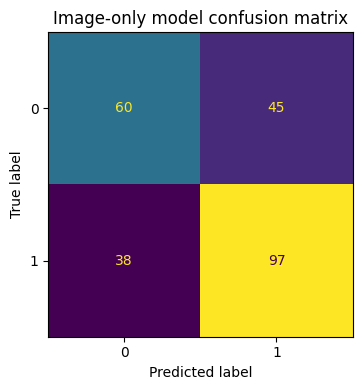

In [ ]:
# =========================
# Cell 12: Confusion matrix
# =========================
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Image-only model confusion matrix")
plt.tight_layout()
plt.show()

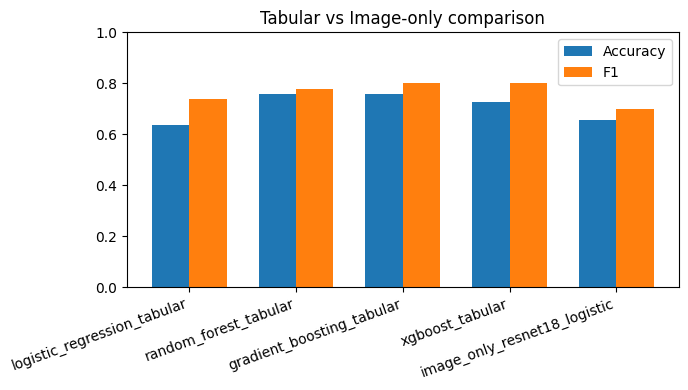

Saved:
- results_imaging/imaging_metrics.txt
- results_imaging/model_comparison.csv
- results_imaging/model_comparison.png


In [ ]:
# =========================
# Cell 13: Save slide-ready outputs
# =========================
os.makedirs("results_imaging", exist_ok=True)

# metrics txt
with open("results_imaging/imaging_metrics.txt", "w") as f:
    f.write("Image-only model: Logistic Regression on frozen ResNet18 embeddings\n")
    f.write(f"Subset size: {len(df)}\n")
    f.write(f"Train size: {len(train_df)}\n")
    f.write(f"Test size: {len(test_df)}\n")
    f.write("Class counts:\n")
    f.write(str(df["Severe"].value_counts().to_dict()) + "\n")
    f.write("Class distribution:\n")
    f.write(str(df["Severe"].value_counts(normalize=True).round(4).to_dict()) + "\n")
    f.write(f"Accuracy: {acc:.4f}\n")
    f.write(f"F1: {f1:.4f}\n")
    f.write(f"Confusion matrix: {cm.tolist()}\n")

# comparison csv against your tabular results
comparison = pd.DataFrame([
    {"model": "logistic_regression_tabular", "accuracy": 0.6364, "f1": 0.7391},
    {"model": "random_forest_tabular", "accuracy": 0.7576, "f1": 0.7778},
    {"model": "gradient_boosting_tabular", "accuracy": 0.7576, "f1": 0.8000},
    {"model": "xgboost_tabular", "accuracy": 0.7273, "f1": 0.8000},
    {"model": "image_only_resnet18_logistic", "accuracy": acc, "f1": f1},
])
comparison.to_csv("results_imaging/model_comparison.csv", index=False)

# bar chart
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(comparison))
w = 0.35
ax.bar(x - w/2, comparison["accuracy"], w, label="Accuracy")
ax.bar(x + w/2, comparison["f1"], w, label="F1")
ax.set_xticks(x)
ax.set_xticklabels(comparison["model"], rotation=20, ha="right")
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Tabular vs Image-only comparison")
plt.tight_layout()
plt.savefig("results_imaging/model_comparison.png", dpi=200)
plt.show()

print("Saved:")
print("- results_imaging/imaging_metrics.txt")
print("- results_imaging/model_comparison.csv")
print("- results_imaging/model_comparison.png")

In [ ]:
# =========================
# Cell 14: Save reusable imaging artifacts for multimodal
# =========================
import json

os.makedirs("results_multimodal", exist_ok=True)

# Save full embeddings table as NPZ so multimodal script/pipeline can reuse it
all_paths = np.concatenate([
    train_df["Path"].astype(str).to_numpy(),
    test_df["Path"].astype(str).to_numpy(),
])
all_embeddings = np.vstack([X_train, X_test])
all_labels = np.concatenate([y_train, y_test])

np.savez_compressed(
    "results_multimodal/imaging_embeddings_resnet18.npz",
    path_to_image=all_paths,
    embeddings=all_embeddings,
    severe=all_labels,
)

# Save image-only metrics as JSON (not only txt)
imaging_metrics = {
    "model": "image_only_resnet18_logistic",
    "n_samples": int(len(df)),
    "train_size": int(len(train_df)),
    "test_size": int(len(test_df)),
    "class_counts": {str(k): int(v) for k, v in df["Severe"].value_counts().to_dict().items()},
    "class_distribution": {
        str(k): float(v) for k, v in df["Severe"].value_counts(normalize=True).round(6).to_dict().items()
    },
    "label_definition": "High-Risk=any(Pneumonia,Edema,Consolidation,Pleural Effusion)",
    "holdout_accuracy": float(acc),
    "holdout_f1": float(f1),
    "holdout_confusion_matrix": cm.tolist(),
}
with open("results_multimodal/imaging_metrics.json", "w") as f:
    json.dump(imaging_metrics, f, indent=2)

print("Saved:")
print("- results_multimodal/imaging_embeddings_resnet18.npz")
print("- results_multimodal/imaging_metrics.json")

In [ ]:
# =========================
# Cell 15: Multimodal fusion (embeddings + age + sex)
# =========================
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, roc_auc_score

# Build multimodal features aligned with current train/test split
X_train_tab = train_df[["age", "sex"]].to_numpy(dtype=np.float32)
X_test_tab = test_df[["age", "sex"]].to_numpy(dtype=np.float32)
X_train_multi = np.hstack([X_train, X_train_tab])
X_test_multi = np.hstack([X_test, X_test_tab])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

search_spaces = {
    "logistic_regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED)),
        ]),
        {"clf__C": [0.01, 0.1, 1.0, 10.0]},
    ),
    "gradient_boosting": (
        GradientBoostingClassifier(random_state=SEED),
        {
            "n_estimators": [100, 200],
            "max_depth": [3, 5],
            "learning_rate": [0.01, 0.1],
        },
    ),
    "mlp": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(max_iter=500, early_stopping=True, random_state=SEED)),
        ]),
        {
            "clf__hidden_layer_sizes": [(128,), (256, 64)],
            "clf__alpha": [1e-4, 1e-3],
        },
    ),
}

try:
    from xgboost import XGBClassifier
    search_spaces["xgboost"] = (
        XGBClassifier(random_state=SEED, eval_metric="logloss", verbosity=0, n_jobs=-1),
        {
            "n_estimators": [100, 200],
            "max_depth": [3, 5],
            "learning_rate": [0.01, 0.1],
        },
    )
except Exception:
    print("xgboost not available; skipping xgboost model")

multi_models = {}
best_name = None
best_est = None
best_f1_cv = -1.0

for name, (estimator, grid) in search_spaces.items():
    gs = GridSearchCV(
        estimator=estimator,
        param_grid=grid,
        cv=cv,
        scoring="f1",
        refit=True,
        n_jobs=-1,
    )
    gs.fit(X_train_multi, y_train)

    cv_acc = []
    cv_f1 = []
    for tr_idx, va_idx in cv.split(X_train_multi, y_train):
        fold_est = gs.best_estimator_
        fold_est.fit(X_train_multi[tr_idx], y_train[tr_idx])
        fold_pred = fold_est.predict(X_train_multi[va_idx])
        cv_acc.append(accuracy_score(y_train[va_idx], fold_pred))
        cv_f1.append(f1_score(y_train[va_idx], fold_pred))

    multi_models[name] = {
        "best_params": gs.best_params_,
        "cv_accuracy_mean": float(np.mean(cv_acc)),
        "cv_accuracy_std": float(np.std(cv_acc)),
        "cv_f1_mean": float(np.mean(cv_f1)),
        "cv_f1_std": float(np.std(cv_f1)),
    }

    if multi_models[name]["cv_f1_mean"] > best_f1_cv:
        best_f1_cv = multi_models[name]["cv_f1_mean"]
        best_name = name
        best_est = gs.best_estimator_

# Final holdout evaluation on the existing test split
best_est.fit(X_train_multi, y_train)
multi_pred = best_est.predict(X_test_multi)

multi_metrics = {
    "accuracy": float(accuracy_score(y_test, multi_pred)),
    "f1": float(f1_score(y_test, multi_pred)),
    "precision": float(precision_score(y_test, multi_pred, zero_division=0)),
    "recall": float(recall_score(y_test, multi_pred, zero_division=0)),
    "confusion_matrix": confusion_matrix(y_test, multi_pred).tolist(),
}
if hasattr(best_est, "predict_proba"):
    multi_prob = best_est.predict_proba(X_test_multi)[:, 1]
    multi_metrics["roc_auc"] = float(roc_auc_score(y_test, multi_prob))

# Save multimodal metrics
multimodal_out = {
    "label_definition": "High-Risk=any(Pneumonia,Edema,Consolidation,Pleural Effusion)",
    "n_samples": int(len(df)),
    "train_size": int(len(train_df)),
    "test_size": int(len(test_df)),
    "feature_schema": "resnet18_embedding + age + sex",
    "best_model_by_cv_f1": best_name,
    "models": multi_models,
    "holdout": multi_metrics,
}

with open("results_multimodal/multimodal_metrics.json", "w") as f:
    json.dump(multimodal_out, f, indent=2)

# Figure 1: Best multimodal confusion matrix
multi_cm = np.array(multi_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(confusion_matrix=multi_cm).plot(ax=ax, colorbar=False, cmap="Purples")
ax.set_title(f"Best multimodal confusion matrix ({best_name})")
plt.tight_layout()
plt.savefig("results_multimodal/multimodal_confusion_matrix_best.png", dpi=200)
plt.show()

# Figure 2: Tabular vs Imaging vs Multimodal (Accuracy + F1)
try:
    tabular_best_acc = float(comparison[comparison["model"].str.contains("tabular")]["accuracy"].max())
    tabular_best_f1 = float(comparison[comparison["model"].str.contains("tabular")]["f1"].max())
except Exception:
    tabular_best_acc = np.nan
    tabular_best_f1 = np.nan

rows = pd.DataFrame([
    {"modality": "Tabular", "accuracy": tabular_best_acc, "f1": tabular_best_f1},
    {"modality": "Imaging", "accuracy": float(acc), "f1": float(f1)},
    {"modality": "Multimodal", "accuracy": multi_metrics["accuracy"], "f1": multi_metrics["f1"]},
])

fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(len(rows))
w = 0.35
ax.bar(x - w/2, rows["accuracy"], w, label="Accuracy")
ax.bar(x + w/2, rows["f1"], w, label="F1")
ax.set_xticks(x)
ax.set_xticklabels(rows["modality"])
ax.set_ylim(0, 1)
ax.set_title("Tabular vs Imaging vs Multimodal")
ax.legend()
plt.tight_layout()
plt.savefig("results_multimodal/multimodal_vs_unimodal_accuracy_f1.png", dpi=200)
plt.show()

print("Best multimodal model:", best_name)
print("Multimodal holdout Accuracy:", round(multi_metrics["accuracy"], 4))
print("Multimodal holdout F1:", round(multi_metrics["f1"], 4))
print("Saved:")
print("- results_multimodal/multimodal_metrics.json")
print("- results_multimodal/multimodal_confusion_matrix_best.png")
print("- results_multimodal/multimodal_vs_unimodal_accuracy_f1.png")